In [2]:
import sklearn
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

from statannotations.Annotator import Annotator

In [9]:
# Load files
bin_file = "data/fold_test_cat_target.csv"
cat_file = "data/fold_test_cat_stageagecancer.csv"

df_tar = pd.read_csv(bin_file)
df_cat = pd.read_csv(cat_file)

# Subset lambda=1
df_tar = df_tar[df_tar["lambda"] == 1]
df_cat = df_cat[df_cat["lambda"] == 1]

In [10]:
# --- Average across repeats within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
    }).reset_index()
    grouped["model"] = model_type
    return grouped

In [11]:
df_tar = df_tar[['fold','repeats','names','lambda','task_f1s']]
df_cat = df_cat[['fold','repeats','names','lambda','task_f1s']]

In [18]:
tar_avg = avg_within_folds(df_tar, 'tar')
cat_avg = avg_within_folds(df_cat, 'cat')

In [21]:
#
df_avg = pd.concat([tar_avg, cat_avg])

# Reshape for plotting
df_melt = df_avg.melt(id_vars=["fold","model"],
                      value_vars=["task_f1s"],
                      var_name="metric", value_name="f1")

## --- Stats ---
#results = []
#for metric in ["task_f1s","stage_f1","age_f1","cancer_f1"]:
#    bin_vals = bin_avg[metric].values
#    cat_vals = cat_avg[metric].values
#    p = wilcoxon(cat_vals, bin_vals).pvalue
#    results.append({"metric":metric, "bin_mean":bin_vals.mean(), "cat_mean":cat_vals.mean(), "p_value":p})


pairs = [(("Task (Survival)","tar"),("Task (Survival)","cat"))]

#stats_df = pd.DataFrame(results)

metric_labels = {
    "task_f1s": "Task (Survival)"
}
df_melt["metric_label"] = df_melt["metric"].map(metric_labels)
#stats_df["metric_label"] = stats_df["metric"].map(metric_labels)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Task (Survival)_tar vs. Task (Survival)_cat: Wilcoxon test (paired samples), P_val:1.484e-01 Stat=7.000e+00


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_60114/4036796302.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",


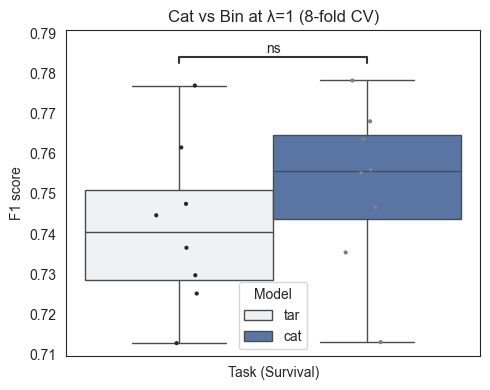

In [26]:
# --- Plot aesthetics ---
sns.set_style("white")
pal = sns.light_palette("#4c72b0", n_colors=2) 


# --- Boxplot ---
plt.figure(figsize=(5,4))
ax = sns.boxplot(data=df_melt, x="metric_label", y="f1", hue="model",
            showcaps=True,
            palette=pal)
sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",
                dodge=True, color="grey", alpha=1, size=3, ax=ax, legend=False)

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="f1", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Cat vs Bin at λ=1 (8-fold CV)")
plt.ylabel("F1 score")
plt.xlabel("")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Task (Survival)_tar vs. Task (Survival)_cat: Wilcoxon test (paired samples), P_val:1.484e-01 Stat=7.000e+00


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_60114/2213505746.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",


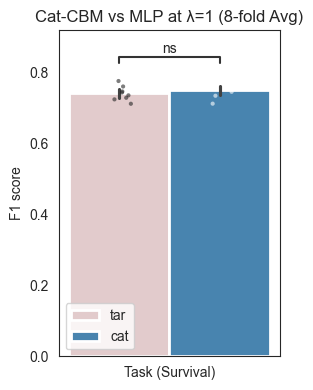

In [55]:
# --- Barplot ---
plt.figure(figsize=(3,4))

# Deep blue palette (from the one you used)
blue = sns.color_palette("Blues", n_colors=5)[3]  # medium/deep blue tone

# Light red (complementary to blue)
red = sns.light_palette("#c44e52", n_colors=5)[1]  # light version of seaborn's red

pal_new = [red, blue]

ax = sns.barplot(data=df_melt, x="metric_label", y="f1", hue="model",
            palette=pal_new, linewidth=2)

sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",
                dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="f1", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Cat-CBM vs MLP at λ=1 (8-fold Avg)")
plt.ylabel("F1 score")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig('barplot_cat_vs_MLP.png')
plt.show()